In [2]:
##시스템에 Graphviz가 설치되어 있지 않은 경우 실행이 안됨.

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import export_graphviz
import pydot

# 데이터셋 불러오기
df = pd.read_csv('bank-full.csv', delimiter=';')

# 범주형 변수 더미 변수로 변환
df = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'month'])

# 수치형 변수 스케일링
scaler = MinMaxScaler()
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
df[num_cols] = scaler.fit_transform(df[num_cols])

# 입력 변수와 출력 변수 분리
X = df.drop('y', axis=1)
y = df['y']

# 훈련 데이터셋과 테스트 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 의사결정나무 모델 생성
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Graphviz 형식으로 변환
dot_data = export_graphviz(clf, out_file=None,
                           feature_names=X.columns,
                           class_names=['no', 'yes'],
                           filled=True, rounded=True,
                           special_characters=True)

# 시각화
graph = pydot.graph_from_dot_data(dot_data)[0]
graph.write_png('decision_tree.png')  # 그래프를 이미지 파일로 저장


In [4]:
!pip install pydotplus


     -------------------------------------- 278.7/278.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py install for pydotplus: started
  Running setup.py install for pydotplus: finished with status 'done'


  DEPRECATION: pydotplus is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559

[notice] A new release of pip is available: 23.0.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image

# 데이터셋 불러오기
df = pd.read_csv('bank-full.csv', delimiter=';')

# 범주형 변수 더미 변수로 변환
df = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'month'])

# 입력 변수와 출력 변수 분리
X = df.drop('y', axis=1)
y = df['y']

# 훈련 데이터셋과 테스트 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 의사결정나무 모델 생성
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# 시각화
dot_data = export_graphviz(dt_clf, out_file=None, 
                           feature_names=X.columns, class_names=['no', 'yes'], 
                           filled=True, rounded=True, special_characters=True)  
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())


dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.318169 to fit



In [10]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 데이터 불러오기
data = pd.read_csv('bank.csv', sep=';')

# 명목형 변수를 수치형 변수로 변환
label_encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == object:
        data[column] = label_encoder.fit_transform(data[column])

# 타겟 변수와 설명 변수 분리
X = data.drop('y', axis=1)
y = data['y']

# 의사결정나무 모델 생성
tree = DecisionTreeClassifier(random_state=0)

# 교차 검증을 위한 KFold 객체 생성
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# 탐색할 최적 하이퍼파라미터 구성
param_grid = {'max_depth': range(1, 11)}

# 최적의 모델을 찾기 위한 GridSearchCV 객체 생성
grid_search = GridSearchCV(tree, param_grid=param_grid, scoring=make_scorer(accuracy_score))

# 교차 검증 수행
grid_search.fit(X, y)

# 결과 출력
print('최적 하이퍼파라미터: ', grid_search.best_params_)
print('최고 정확도: {:.3f}'.format(grid_search.best_score_))


최적 하이퍼파라미터:  {'max_depth': 8}
최고 정확도: 0.892



[notice] A new release of pip is available: 23.0.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


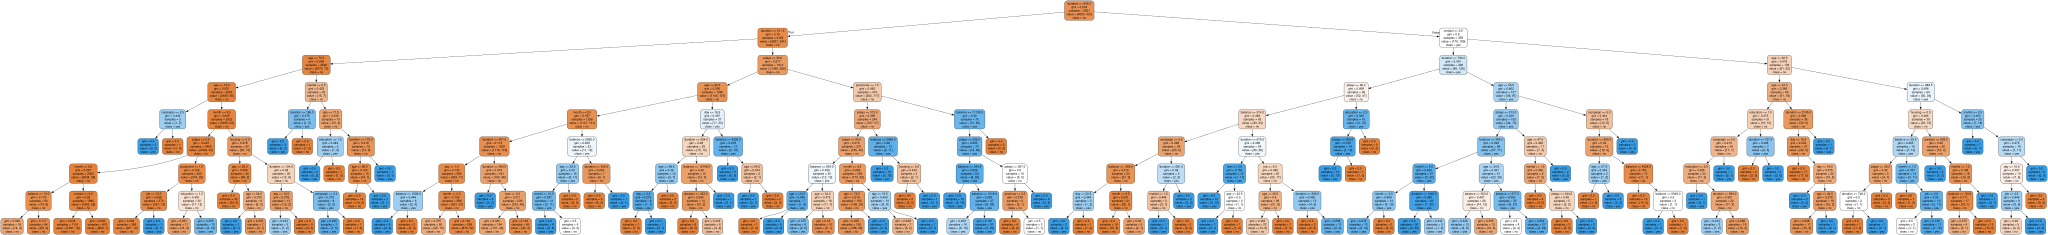

In [14]:
# 최적 하이퍼파라미터로 의사결정나무 모델 생성
tree = DecisionTreeClassifier(max_depth=grid_search.best_params_['max_depth'], random_state=0)

# 모델 학습
tree.fit(X, y)

# 시각화를 위한 graphviz 패키지 설치
!pip install graphviz

# 시각화를 위한 graphviz 패키지와 의사결정나무 모델을 연결하는 graphviz 객체 생성
from sklearn.tree import export_graphviz
from IPython.display import display
import graphviz

dot_data = export_graphviz(tree, out_file=None, filled=True, rounded=True, feature_names=X.columns, class_names=['no', 'yes'])
display(graphviz.Source(dot_data))


In [35]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# 데이터 불러오기
data = pd.read_csv('bank.csv', sep=';')

# 명목형 변수를 수치형 변수로 변환
label_encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == object:
        data[column] = label_encoder.fit_transform(data[column])

# 타겟 변수와 설명 변수 분리
X = data.drop('y', axis=1)
y = data['y']

# 훈련 데이터와 테스트 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# 의사결정나무 모델 생성
tree = DecisionTreeClassifier(max_depth=grid_search.best_params_['max_depth'], random_state=0)

# 가지치기를 적용하기 전 모델 학습 및 예측
tree.fit(X_train, y_train)
y_pred_before_pruning = tree.predict(X_test)
accuracy_before_pruning = accuracy_score(y_test, y_pred_before_pruning)

# 가지치기를 적용한 모델 학습 및 예측
pruned_tree = DecisionTreeClassifier(max_depth=grid_search.best_params_['max_depth'], random_state=0, ccp_alpha=0.001)
pruned_tree.fit(X_train, y_train)
y_pred_after_pruning = pruned_tree.predict(X_test)
accuracy_after_pruning = accuracy_score(y_test, y_pred_after_pruning)

# 결과 출력
print('가지치기를 적용하기 전 정확도: {:.3f}'.format(accuracy_before_pruning))
print('가지치기를 적용한 후 정확도: {:.3f}'.format(accuracy_after_pruning))


NameError: name 'grid_search' is not defined

In [36]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Load the Bank Marketing data set
data = pd.read_csv("bank-additional.csv", sep=";")

# Drop irrelevant features(관련없는 기능 제거)
data.drop(columns=['contact', 'month', 'day_of_week', 'duration'], inplace=True)

# Encode categorical variables using one-hot encoding(범주형 변수 인코딩)
cat_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']
for var in cat_vars:
    dummy_vars = pd.get_dummies(data[var], prefix=var)
    data = pd.concat([data, dummy_vars], axis=1)
    data.drop(columns=[var], inplace=True)

# Handle missing values using mean imputation(결측값 처리)
imputer = SimpleImputer(strategy='mean')
num_vars = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
data[num_vars] = imputer.fit_transform(data[num_vars])

# Split the data into training and testing sets
X = data.drop(columns=["y"])
y = data["y"].map({"no": 0, "yes": 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [37]:
# 필요한 패키지 불러오기
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score
import graphviz

# 데이터 불러오기
df = pd.read_csv('bank-additional.csv', delimiter=';')

# 변수 선택
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 문자형 변수를 더미 변수로 변환
X = pd.get_dummies(X)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 의사결정나무 모델 구축
dtc = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc.fit(X_train, y_train)

# F1 score 계산
y_pred = dtc.predict(X_test)
f1 = f1_score(y_test, y_pred, pos_label='yes')
print(f1)

# 의사결정나무 시각화
dot_data = dtc.export_graphviz(dtc, out_file=None,
                                feature_names=X.columns,
                                class_names=['no', 'yes'],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("dt_bank")  # 그래프 저장
graph.view()  # 그래프 출력


0.45263157894736844


AttributeError: 'DecisionTreeClassifier' object has no attribute 'export_graphviz'

In [33]:
from sklearn.tree import export_graphviz
import graphviz

# Generate a graphviz object from the decision tree
dot_data = export_graphviz(dtc_pruned, out_file=None, 
                           feature_names=X.columns, class_names=['No', 'Yes'], filled=True)

# Use graphviz to create a graph from the dot data
graph = graphviz.Source(dot_data)

# Display the graph
graph


NameError: name 'dtc_pruned' is not defined

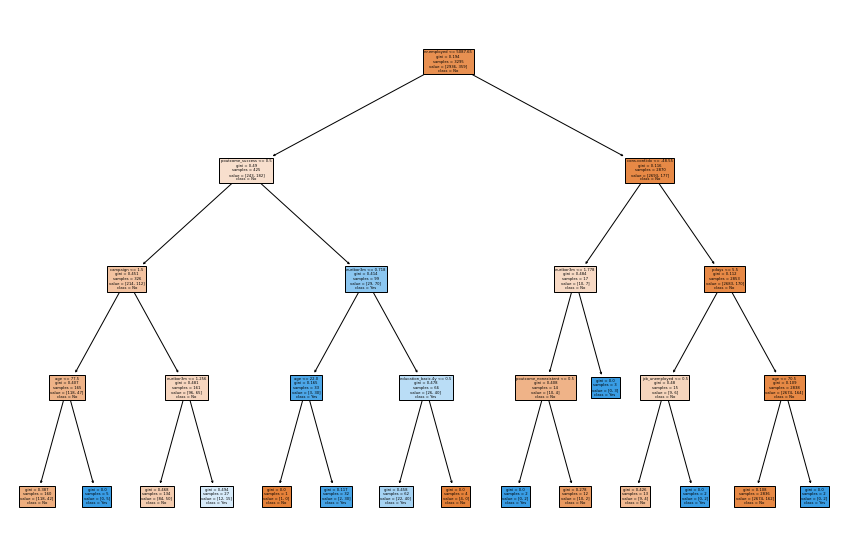

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Instantiate a DecisionTreeClassifier with max_depth=4 and criterion='gini'
dtc = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)

# Train the decision tree on the training data
dtc.fit(X_train, y_train)

# Plot the decision tree
plt.figure(figsize=(15,10))
plot_tree(dtc, filled=True, feature_names=X.columns, class_names=['No', 'Yes'])
plt.show()


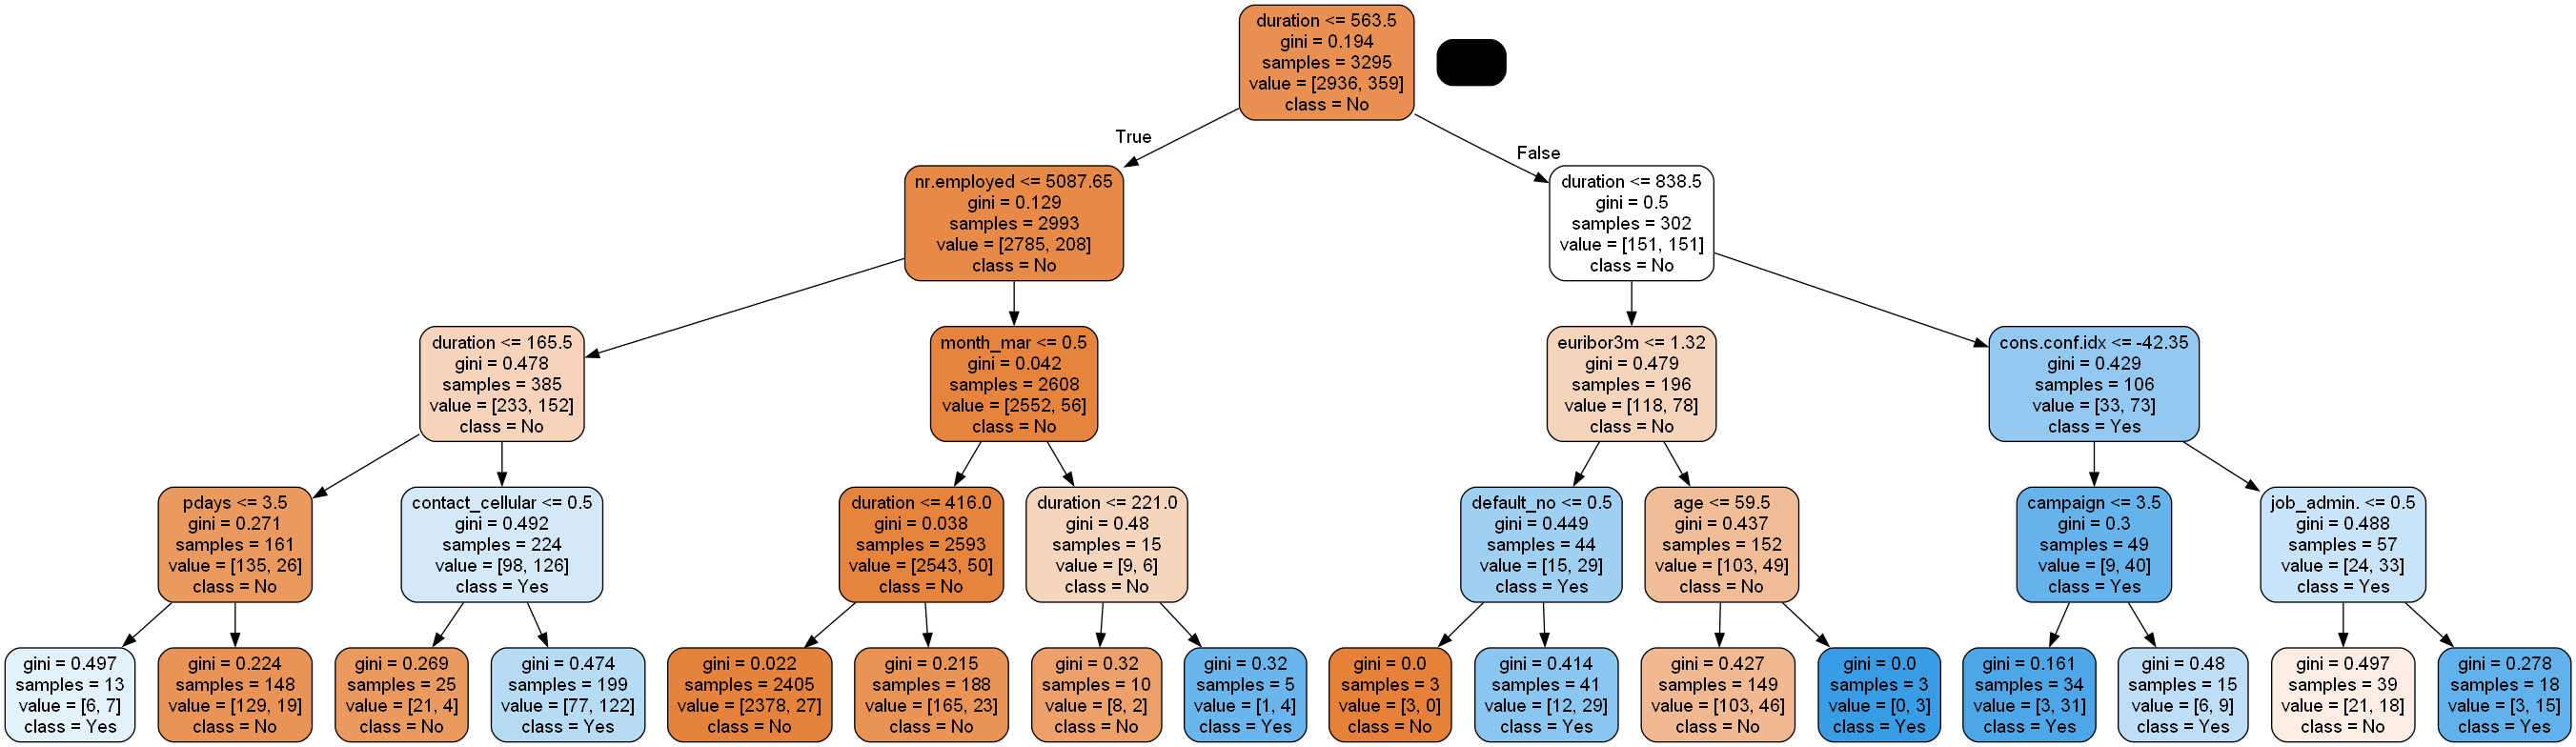

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image

# Instantiate a DecisionTreeClassifier with max_depth=4 and criterion='gini'
dtc = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)

# Train the decision tree on the training data
dtc.fit(X_train, y_train)

# Export the decision tree as a dot file
dot_data = export_graphviz(dtc, out_file=None, filled=True, rounded=True,
                           feature_names=X.columns, class_names=['No', 'Yes'])

# Create a PyDotPlus graph from the dot data
graph = pydotplus.graph_from_dot_data(dot_data)

# Show the decision tree graph
Image(graph.create_png(), width=1000, height=800)


In [7]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Compute accuracy on the test set
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8968446601941747


In [8]:
from sklearn.metrics import confusion_matrix, classification_report

# Compute confusion matrix on the test set
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", conf_mat)

# Compute precision, recall, F1 score, and support on the test set
report = classification_report(y_test, y_pred, target_names=['No', 'Yes'])
print("Classification report:\n", report)


Confusion matrix:
 [[722  10]
 [ 75  17]]
Classification report:
               precision    recall  f1-score   support

          No       0.91      0.99      0.94       732
         Yes       0.63      0.18      0.29        92

    accuracy                           0.90       824
   macro avg       0.77      0.59      0.62       824
weighted avg       0.88      0.90      0.87       824



Accuracy with pruning: 0.8883495145631068


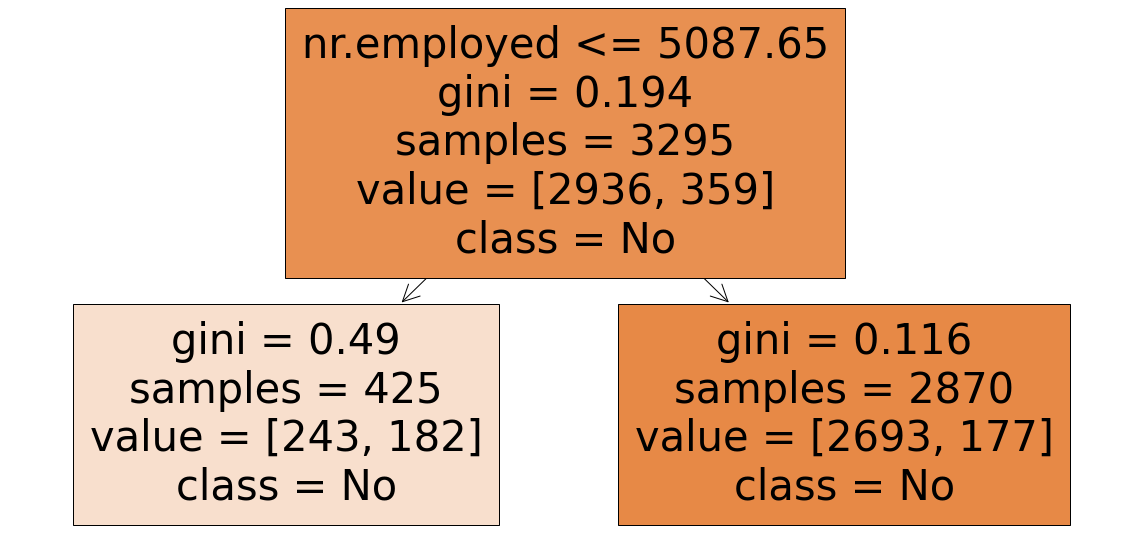

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Fit decision tree with pruning
clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.02)
clf_pruned.fit(X_train, y_train)

# Make predictions on the test set with pruned tree
y_pred_pruned = clf_pruned.predict(X_test)

# Evaluate the accuracy of pruned tree
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print("Accuracy with pruning:", accuracy_pruned)

# Visualize the pruned tree
plt.figure(figsize=(20,10))
plot_tree(clf_pruned, filled=True, feature_names=X.columns, class_names=['No', 'Yes'])
plt.show()


In [10]:
from sklearn.metrics import f1_score

y_pred_before_pruning = dt.predict(X_test)
f1_before_pruning = f1_score(y_test, y_pred_before_pruning)
print("F1 score before pruning: {:.4f}".format(f1_before_pruning))


NameError: name 'dt' is not defined

In [11]:
y_pred_after_pruning = pruned_dt.predict(X_test)
f1_after_pruning = f1_score(y_test, y_pred_after_pruning)
print("F1 score after pruning: {:.4f}".format(f1_after_pruning))


NameError: name 'pruned_dt' is not defined

In [20]:
import graphviz
from sklearn.tree import export_graphviz

# 가지치기 적용한 의사결정나무 시각화
dot_data_pruned = export_graphviz(
    dt_pruned, 
    feature_names=X.columns, 
    class_names=['no', 'yes'], 
    filled=True, 
    rounded=True, 
    special_characters=True
)

graph_pruned = graphviz.Source(dot_data_pruned)
graph_pruned


NameError: name 'dt_pruned' is not defined

In [22]:
!pip install six



[notice] A new release of pip is available: 23.0.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


가지치기 전 의사결정나무의 성능 평가
              precision    recall  f1-score   support

          no       0.93      0.92      0.93       732
         yes       0.44      0.47      0.45        92

    accuracy                           0.87       824
   macro avg       0.69      0.70      0.69       824
weighted avg       0.88      0.87      0.88       824

혼동 행렬
[[677  55]
 [ 49  43]]
F1 Score
0.45263157894736844
가장 높은 테스트 정확도를 가진 ccp_alpha : 0.0012


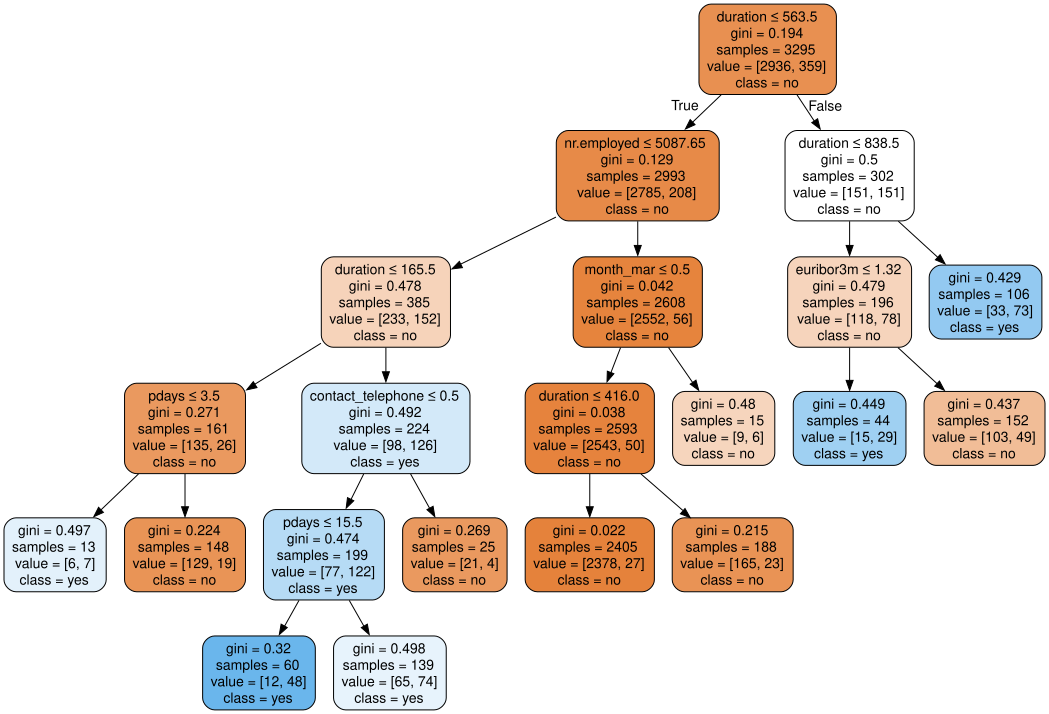

In [27]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
#from sklearn.externals.six import StringIO
from six import StringIO
from IPython.display import Image
import pydotplus
import pandas as pd
import numpy as np

# 데이터 불러오기
bank_data = pd.read_csv('bank-additional.csv', sep=';')

# 레이블 인코딩
le = LabelEncoder()
bank_data['y'] = le.fit_transform(bank_data['y'])

# 독립변수와 종속변수 분리
X = bank_data.iloc[:, :-1]
y = bank_data.iloc[:, -1]

# 범주형 변수와 연속형 변수 분리
categorical = [col for col in X.columns if X[col].dtype == 'object']
continuous = [col for col in X.columns if col not in categorical]

# 범주형 변수를 더미변수로 변환
X = pd.get_dummies(X, columns=categorical)

# train/test 데이터셋 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 가지치기 전 의사결정나무 모델 구축
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 가지치기 전 의사결정나무 시각화
dot_data = StringIO()
export_graphviz(dt, out_file=dot_data, filled=True, rounded=True, special_characters=True, feature_names=X.columns)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

# 예측 및 평가
y_pred = dt.predict(X_test)
print("가지치기 전 의사결정나무의 성능 평가")
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
print("혼동 행렬")
print(confusion_matrix(y_test, y_pred))
print("F1 Score")
print(f1_score(y_test, y_pred))

# 가지치기
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
dts = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt.fit(X_train, y_train)
    dts.append(dt)

# ccp_alpha 별 정확도 저장
train_scores = [dt.score(X_train, y_train) for dt in dts]
test_scores = [dt.score(X_test, y_test) for dt in dts]

# 가장 높은 ccp_alpha 선택
optimal_ccp_alpha = ccp_alphas[np.argmax(test_scores)]
print(f"가장 높은 테스트 정확도를 가진 ccp_alpha : {optimal_ccp_alpha:.4f}")

# 가지치기 후 의사결정나무 모델 구축
dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)
dt_pruned.fit(X_train, y_train)

# 가지치기 후 의사결정나무 시각화
dot_data = export_graphviz(dt_pruned, 
                           out_file=None, 
                           feature_names=X.columns, 
                           class_names=['no', 'yes'], 
                           filled=True, 
                           rounded=True, 
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph
